# Least Squares (v2)

**A note on this document**
This document is known as a Jupyter notebook; it allows text and executable code to coexist in a very easy-to-read format. Blocks can contain text or executable code. For blocks containing code, press `Shift + Enter`, `Ctrl + Enter`, or click the arrow on the block to run the code. Earlier blocks of code need to be run for the later blocks of code to work.

## Least Squares Regression

We want to find the straight line that best fits a set of measured data. Let the inputs be $\mathbf{x} = (x_1, x_2, \cdots, x_n)$ and the corresponding measurements be $\mathbf{y} = (y_1, y_2, \cdots, y_n)$.

The goal is to find $m$ and $b$ such that $y = mx + b$ best approximates the linear relationship between $x$ and $y$.

Let's first plot the data.

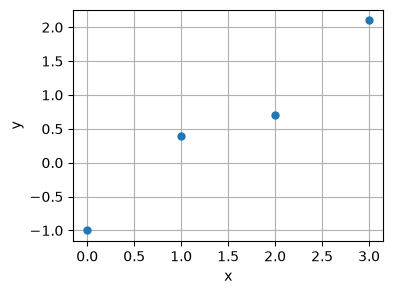

In [41]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3])
y = np.array([-1, 0.4, 0.7, 2.1])

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, y, "o", markersize=5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
plt.show()

First, we can rewrite the line equation as $y = \mathbf{c} \cdot \mathbf{q}$, where

$\mathbf{c} = \begin{bmatrix} x & 1\end{bmatrix}$ and $\mathbf{q} = \begin{bmatrix} m \\ b\end{bmatrix} $. That is,

$y = mx + b = \begin{bmatrix} x & 1\end{bmatrix} \begin{bmatrix} m \\ b\end{bmatrix} = \mathbf{c} \cdot \mathbf{q}$ 

Given $\mathbf{x} = (x_1, x_2, \cdots, x_n)$ and $\mathbf{y} = (y_1, y_2, \cdots, y_n)$, we can obtain

$\begin{bmatrix} -1 \\ 0.4 \\ 0.7 \\ 2.1\end{bmatrix} = \begin{bmatrix} 0 & 1 \\ 1 & 1 \\2 & 1 \\3 & 1 \end{bmatrix} \begin{bmatrix} m \\ b\end{bmatrix}$  or $\mathbf{y} = C\mathbf{q}$, 

where

$C = \begin{bmatrix} x_1 & 1 \\ x_2 & 1 \\x_3 & 1 \\x_4 & 1 \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ 1 & 1 \\2 & 1 \\3 & 1 \end{bmatrix} $.

We can create the $C$ matrix using `np.column_stack`, which stacks 1-D arrays side by side as columns.

In [42]:
# Stack x and a vector of ones, [1, 1, ..., 1], side by side as columns.
# The result is an n x 2 matrix.
C = np.column_stack([x, np.ones(len(x))   ]   )
print(C)

[[0. 1.]
 [1. 1.]
 [2. 1.]
 [3. 1.]]


Now use `np.linalg.lstsq` to solve for $\mathbf{q}$:

In [43]:
q = np.linalg.lstsq(C, y)[0]
print(q)

# or unpack the solution directly
m, b = np.linalg.lstsq(C, y)[0]
print(f"m = {m:.2f}, b = {b:.2f}")

[ 0.96 -0.89]
m = 0.96, b = -0.89


With $m=0.96$ and $b=-0.89$, the best fitting line is

$y = 0.96x-0.89$

Let's plot the line, $y = mx + b$ along with the data.

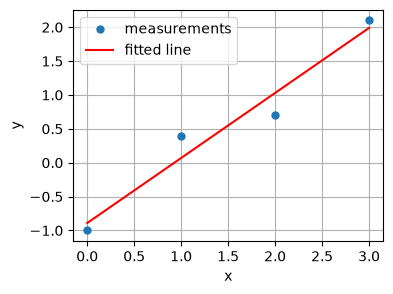

In [44]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, y, "o", label="measurements", markersize=5)
ax.plot(x, m * x + b, "r", label="fitted line")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True)
plt.show()

## Free-fall example

Work through the `falling_body.ipynb` notebook, which fits a model to data in three different ways: `Polynomial.fit`, the pseudo-inverse, and `np.linalg.lstsq`.

## 🚚 Deliverables

**Push your code to your repo, and submit the requested plots and answers in Gradescope.**

Questions marked ✍️ need a written answer in your own words. They are graded on reasoning that refers to *your* results, so a generic answer will not earn full credit.

### Deliverable 1

You want to determine the value of a capacitor. You set up an RC circuit with a 1 k$\Omega$ resistor and connect it to a nominally 5 V DC supply. After the capacitor has charged, you disconnect the supply and record the capacitor voltage as it discharges.

<div>
<center>
<img src="./figures/RC_Circuit.png" width="200"/>
</center>
</div>

The capacitor voltage follows

$$v(t) = v_0 e^{-t/\tau}, \quad t\geq 0,$$

where $\tau = RC$ is the time constant. Use the following measurements of $v(t)$.

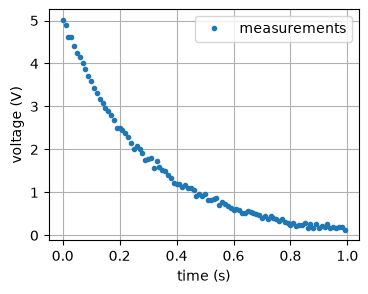

In [45]:
t = np.arange(0, 1, 0.01)

v = np.array(
    [
        5.01244283,
        4.88438776,
        4.61866927,
        4.60894011,
        4.41004693,
        4.23826769,
        4.14274337,
        4.00588297,
        3.88199414,
        3.70225232,
        3.58355439,
        3.43455927,
        3.30474357,
        3.18078036,
        3.07476507,
        2.96726969,
        2.89063642,
        2.80789063,
        2.69423508,
        2.49191736,
        2.50954028,
        2.44712497,
        2.38835945,
        2.30025698,
        2.13790825,
        2.01659547,
        2.07912399,
        2.00577069,
        1.92508211,
        1.7565095,
        1.7865158,
        1.78987426,
        1.56199575,
        1.72613664,
        1.58584813,
        1.51952741,
        1.49326173,
        1.40786616,
        1.32605959,
        1.22720959,
        1.19448915,
        1.20467148,
        1.12784961,
        1.1784009,
        1.10309822,
        1.09199671,
        1.05440677,
        0.92322795,
        0.95694284,
        0.90854489,
        0.97174071,
        0.81287511,
        0.82147023,
        0.8520071,
        0.86750312,
        0.70163675,
        0.77931194,
        0.73922824,
        0.69029541,
        0.6377564,
        0.58477345,
        0.61595619,
        0.59972651,
        0.51719116,
        0.50915179,
        0.57589605,
        0.5485081,
        0.51194423,
        0.50774903,
        0.46536343,
        0.40064362,
        0.4548967,
        0.37060314,
        0.44504432,
        0.40862983,
        0.38155415,
        0.32950763,
        0.38447669,
        0.31214141,
        0.29181047,
        0.24943998,
        0.28925818,
        0.22684326,
        0.25104928,
        0.24648863,
        0.29750812,
        0.16686111,
        0.26215788,
        0.17941954,
        0.25641971,
        0.17907152,
        0.22507161,
        0.1988562,
        0.26396801,
        0.17906211,
        0.18801865,
        0.16303685,
        0.19193568,
        0.18761862,
        0.12386653,
    ]
)

# plot the data
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(t, v, "o", label="measurements", markersize=3)
ax.set_xlabel("time (s)")
ax.set_ylabel("voltage (V)")
ax.legend()
ax.grid(True)
plt.show()

**1a ✍️ Derivation.** $v(t)$ is a nonlinear function of $\tau$. Assuming $v_0$ is known, transform the model into a linear least-squares problem $\mathbf{y} = C\mathbf{q}$. State what $\mathbf{y}$, $C$, and $\mathbf{q}$ are and give their dimensions. Write your derivation in the cell below using LaTeX.

The theoretical exponential model is

$$
v(t) = v_0 e^{-t/\tau},
$$

where $v_0$ and $\tau$ are known constants. Taking the natural logarithm of both sides gives

$$
\begin{aligned}
\ln v(t)
&= \ln\left(v_0 e^{-t/\tau}\right) \\
&= \ln v_0 + \ln\left(e^{-t/\tau}\right) \\
&= -\frac{1}{\tau}t + \ln v_0.
\end{aligned}
$$

We fit the logarithm of the measured data using an unknown slope $m$ and intercept $b$. Their theoretical values are $-1/\tau$ and $\ln v_0$, respectively, but we estimate them by regression.

For $n$ measurements with $y_i > 0$, we write

$$
\begin{bmatrix}
\ln y_1 \\
\ln y_2 \\
\vdots \\
\ln y_n
\end{bmatrix}
\approx
\begin{bmatrix}
t_1 & 1 \\
t_2 & 1 \\
\vdots & \vdots \\
t_n & 1
\end{bmatrix}
\begin{bmatrix}
m \\
b
\end{bmatrix}.
$$

The measurement vector has dimensions $n \times 1$, the time-and-ones matrix has dimensions $n \times 2$, and the coefficient vector has dimensions $2 \times 1$.

**1b.** Assume $v_0$ is exactly the nominal 5 V. Use least squares to estimate $\tau $, then compute the capacitance. Plot the measurements together with your fitted curve (axis labels with units, and a legend).

[-3.49040256]
-3.4904025641961134
tau = 0.2865 s, C = 286.4999041250 uF


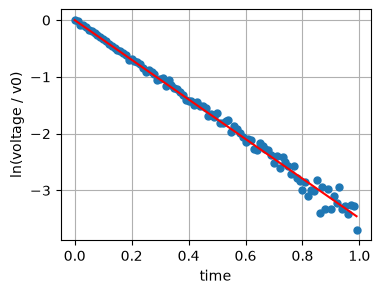

In [46]:
v0 = 5  # nominal supply voltage, V
R = 1e3  # resistance, ohm

# print(len(v))
# print(len(t))

C1 = np.column_stack([t])

v1 = np.zeros(100)

for i in range(0, 100):
    v1[i] = np.log(v[i] / v0)

# print(v1)

q = np.linalg.lstsq(C1, v1)[0]

m1 = q[0]
print(q)
print(m1)




tau_fixed = -1 / m1 # replace this line
capacitance = -1/(R*m1)  # replace this line
print(f"tau = {tau_fixed:.4f} s, C = {capacitance * 1e6:.10f} uF")

# # Plot the measurements with your fitted curve.


fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(t, v1, "o", markersize=5)
ax.plot(t, m1 * t , "r", label="fitted line")
ax.set_xlabel("time")
ax.set_ylabel("ln(voltage / v0)")
ax.grid(True)
plt.show()


**1c.** The supply is only *nominally* 5 V, so the capacitor may not start at exactly 5 V. Repeat the fit, this time estimating $v_0$ from the data together with $\tau$. Report both, and plot the new fitted curve.

[[0.   1.  ]
 [0.01 1.  ]
 [0.02 1.  ]
 [0.03 1.  ]
 [0.04 1.  ]
 [0.05 1.  ]
 [0.06 1.  ]
 [0.07 1.  ]
 [0.08 1.  ]
 [0.09 1.  ]
 [0.1  1.  ]
 [0.11 1.  ]
 [0.12 1.  ]
 [0.13 1.  ]
 [0.14 1.  ]
 [0.15 1.  ]
 [0.16 1.  ]
 [0.17 1.  ]
 [0.18 1.  ]
 [0.19 1.  ]
 [0.2  1.  ]
 [0.21 1.  ]
 [0.22 1.  ]
 [0.23 1.  ]
 [0.24 1.  ]
 [0.25 1.  ]
 [0.26 1.  ]
 [0.27 1.  ]
 [0.28 1.  ]
 [0.29 1.  ]
 [0.3  1.  ]
 [0.31 1.  ]
 [0.32 1.  ]
 [0.33 1.  ]
 [0.34 1.  ]
 [0.35 1.  ]
 [0.36 1.  ]
 [0.37 1.  ]
 [0.38 1.  ]
 [0.39 1.  ]
 [0.4  1.  ]
 [0.41 1.  ]
 [0.42 1.  ]
 [0.43 1.  ]
 [0.44 1.  ]
 [0.45 1.  ]
 [0.46 1.  ]
 [0.47 1.  ]
 [0.48 1.  ]
 [0.49 1.  ]
 [0.5  1.  ]
 [0.51 1.  ]
 [0.52 1.  ]
 [0.53 1.  ]
 [0.54 1.  ]
 [0.55 1.  ]
 [0.56 1.  ]
 [0.57 1.  ]
 [0.58 1.  ]
 [0.59 1.  ]
 [0.6  1.  ]
 [0.61 1.  ]
 [0.62 1.  ]
 [0.63 1.  ]
 [0.64 1.  ]
 [0.65 1.  ]
 [0.66 1.  ]
 [0.67 1.  ]
 [0.68 1.  ]
 [0.69 1.  ]
 [0.7  1.  ]
 [0.71 1.  ]
 [0.72 1.  ]
 [0.73 1.  ]
 [0.74 1.  ]
 [0.75 1.  ]
 [0.76 1.  ]

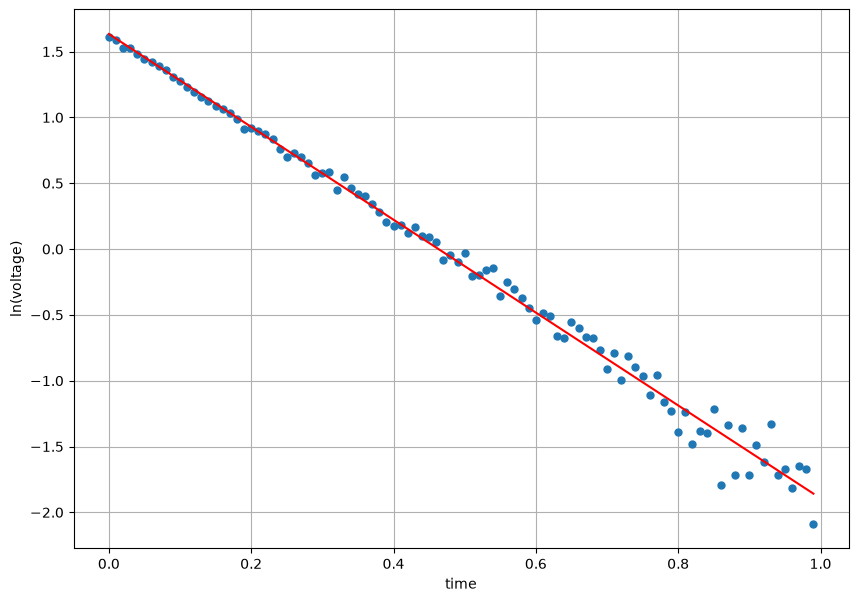

In [47]:
import math
R = 1e3

C2 = np.column_stack([t,  np.ones([len(t)]) ] )

print(C2)

v2 = np.zeros(100)

for i in range(0, 100):
    v2[i] = np.log(v[i])

print(v2)
q = np.linalg.lstsq(C2, v2)[0]

m2, b2 = q
print(m2)
print(b2)



tau_free =-1 / m2  # replace this line
v0_free = math.exp(b2)  # replace this line
print(f"tau = {tau_free:.4f} s, v0 = {v0_free:.3f} V")

# Plot the measurements with your new fitted curve.

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(t, v2, "o", markersize=5)
ax.plot(t, m2 * t + b2, "r", label="fitted line")
ax.set_xlabel("time")
ax.set_ylabel("ln(voltage)")
ax.grid(True)
plt.show()

**1d ✍️** Plot the residuals of both fits (1b and 1c) versus time, in the log domain where you did the fitting. Which estimate of $\tau$ do you trust more? Support your answer with the residual plot, and ask yourself whether your estimated $v_0$ is physically possible.

[ 2.48547465e-03  1.15100602e-02 -9.52323434e-03  2.32720840e-02
  1.40635213e-02  9.23683786e-03  2.13444596e-02  2.26542902e-02
  2.61432679e-02  1.36396879e-02  1.59574982e-02  8.39498139e-03
  4.76927706e-03  1.44098383e-03  2.44694489e-03  1.76470590e-03
  1.05031903e-02  1.63640595e-02  9.94888388e-03 -3.32089870e-02
  8.74218140e-03  1.84604799e-02  2.90573593e-02  2.63755245e-02
 -1.19133993e-02 -3.54265928e-02  3.00134006e-02  2.89991508e-02
  2.28434269e-02 -3.38925676e-02  1.79500994e-02  5.47322540e-02
 -4.65447613e-02  8.82806890e-02  3.84183214e-02  3.06023571e-02
  4.80698186e-02  2.40862327e-02 -8.73107617e-04 -4.34379463e-02
 -3.55582823e-02  7.83403795e-03 -2.31560158e-02  5.55935401e-02
  2.44620002e-02  4.92511060e-02  4.91255726e-02 -4.88278158e-02
  2.19437007e-02  4.94836277e-03  1.07097100e-01 -3.65104022e-02
  8.91184020e-03  8.03150277e-02  1.33243302e-01 -4.40559611e-02
  9.58436467e-02  7.79429932e-02  4.43599322e-02  1.00713711e-04
 -5.17271456e-02  3.51282

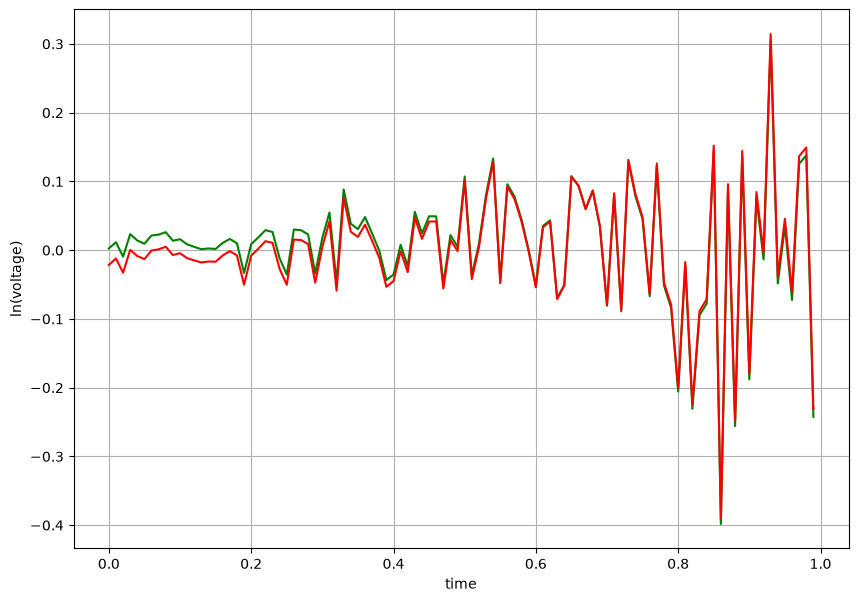

In [48]:
# Plot the residuals of both fits versus time.
#residuals are the difference between each point and the line. 

residuals1 = np.zeros(100)
residuals2 = np.zeros(100)


for i in range(100):
    residuals1[i] = v1[i] - m1*t[i]

print(residuals1)

for i in range(100):
    residuals2[i] = v2[i] - (m2*t[i] + b2)

print(residuals2)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(t, residuals1, "g", label="model 1 residuals")
ax.plot(t, residuals2, "r", label="model 2 residuals")
ax.set_xlabel("time")
ax.set_ylabel("ln(voltage)")
ax.grid(True)
plt.show()





✍️ *Your answer here.*

I trust the one where we do not accept v0's nominal value and instead calculate it as part of the regression. This is because we don't falsely assume more information than we have and so get a result closer to reality (likely). 

**1e ✍️** `falling_body.ipynb` showed three ways to solve a least-squares problem: `Polynomial.fit`, the pseudo-inverse, and `np.linalg.lstsq`. Which of them can you use for the fit in 1b, where the model has **no constant term**? Try each one and explain any differences you see.

In [49]:
from numpy.polynomial import Polynomial  # the Polynomial class from NumPy's polynomial package

p = Polynomial.fit(t, v1, deg=1).convert()
print("Polynomial.fit [intercept, slope]:", p.coef)

q_pinv = np.linalg.pinv(C1) @ v1
print("pseudo-inverse slope:", q_pinv[0])

q_lstsq = np.linalg.lstsq(C1, v1)[0]
print("lstsq slope:", q_lstsq[0])

Polynomial.fit [intercept, slope]: [ 0.02403457 -3.52663558]
pseudo-inverse slope: -3.4904025641961143
lstsq slope: -3.4904025641961134


✍️ *Your answer here.*

### Deliverable 2

The following dataset describes housing in California. Each row is one district (census block group), with summary statistics from the 1990 U.S. census.

In [ ]:
from pathlib import Path
import tarfile

import pandas as pd
import requests


def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        tarball_path.parent.mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        # requests works on macOS, Windows, and Ubuntu without extra SSL certificate setup.
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        tarball_path.write_bytes(response.content)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))


housing = load_housing_data()
housing.head()  # The first five rows of data.

Since the dataset includes geographic information (latitude and longitude), it is a good idea to create a scatter plot of all the districts to visualize the data.

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4), layout="constrained")

panels = [
    # (label, marker size, marker color)
    ("population", housing["population"] / 100, "median_house_value"),
    ("median_income", housing["median_income"] * 2, "median_income"),
    ("median_house_value", housing["median_house_value"] / 50000, "median_house_value"),
]

for ax, (label, size, color) in zip(axes, panels):
    housing.plot(
        ax=ax,
        kind="scatter",
        x="longitude",
        y="latitude",
        s=size,
        c=color,
        cmap="jet",
        colorbar=True,
        label=label,
        grid=True,
    )
plt.show()

We want to predict the median house value $v$ (in dollars) of a district from its median income $x$ (in tens of thousands of dollars) and its population $y$, using the linear model

$$v = w_0 + w_1 x + w_2 y.$$

**2a.** Use least squares to find $w_0$, $w_1$, and $w_2$. Then complete `predict()` so that it returns your model's prediction. The plotting code below calls `predict()`, so it works whichever way you arrange the columns of your matrix.

In [ ]:
value = housing["median_house_value"].to_numpy()
income = housing["median_income"].to_numpy()
population = housing["population"].to_numpy()

# Fit the model here.


def predict(income, population):
    """Return the model's predicted median house value, in dollars."""
    return np.zeros_like(income)  # replace this line

In [ ]:
# Plot the fitted plane.
income_grid, population_grid = np.meshgrid(np.linspace(0, 15, 100), np.linspace(0, 35000, 100))
value_grid = predict(income_grid, population_grid)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
surf = ax.plot_surface(income_grid, population_grid, value_grid, cmap="coolwarm")
ax.set_box_aspect(None, zoom=0.85)  # leave room for the z-axis label
fig.colorbar(surf, shrink=0.6, pad=0.1)
ax.set_xlabel("median income ($10k)")
ax.set_ylabel("population")
ax.set_zlabel("median house value ($)", labelpad=12)
plt.show()

**2b ✍️** According to your model, how much does the predicted median house value change when the median income rises by \$10,000? When the population rises by 1,000 people? Give numbers with units.

✍️ *Your answer here.*

**2c ✍️** Your $|w_2|$ is thousands of times smaller than $w_1$. Does that mean population matters much less than income? Standardize both features (subtract the mean and divide by the standard deviation), refit the model, and compare the coefficients again. Explain what changed and why.

In [ ]:
# Standardize the features and refit here.

✍️ *Your answer here.*

In Gradescope, submit your plots from Deliverables 1 and 2 and your answers to the ✍️ questions.

## ✅ Check-off

After you submit, you will have a short (about 2 minutes) check-off with your instructor. You will be asked to explain your work without notes, for example:

- how you turned the RC model into a linear least-squares problem,
- the shape of each $C$ matrix you built and what each of its columns means,
- why your answers to 1d and 2c come out the way they do.

Be ready to explain every line of code you submit.